In [28]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association  # Cramer's V

In [29]:
df_demo = pd.read_csv("df_final_demo.txt")

In [30]:
df_experiment = pd.read_csv("df_final_experiment_clients.txt")

In [31]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


- Null values and duplicates for both datasets

In [45]:
df_demo.isna().sum()

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64

In [48]:
df_demo = df_demo.dropna()

In [49]:
df_demo.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gendr               0
num_accts           0
bal                 0
calls_6_mnth        0
logons_6_mnth       0
dtype: int64

In [47]:
df_demo.duplicated().sum()

np.int64(0)

In [32]:
df_experiment.isna().sum()

client_id        0
Variation    20109
dtype: int64

In [44]:
df_experiment.duplicated().sum()

np.int64(0)

In [33]:
# Drop all the null values from "Variation" because they are not relevant for the analysis 
df_experiment.dropna(axis = 0, inplace=True)

- Merge both tables to know which client_id corresponds to "Test"  or "Control"

In [34]:
df_clients = pd.merge(df_demo, df_experiment, on = "client_id")
df_clients.head() 

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


### Concat 2 footprint datasets 

In [35]:
df_footprint1 = pd.read_csv("df_final_web_data_pt_1.txt")
df_footprint2 = pd.read_csv("df_final_web_data_pt_2.txt")


In [36]:
# Combining 2 footprint datasets 

df_footprint = pd.concat([df_footprint1, df_footprint2], axis = 0)
df_footprint

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


- Check nulls and duplicates

In [37]:
df_footprint.isna().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [38]:
df_footprint.duplicated().sum()

np.int64(10764)

In [ ]:
# Seems that actually there are not duplicated, there are differences in date_time, hence not removing them 

df_footprint[df_footprint.duplicated()]

,client_id,visitor_id,visit_id,process_step,date_time
365,9358626,148475529_63668223960,223297395_36250329195_832161,start,2017-04-28 12:27:28
368,5376894,622509328_44408201172,688984457_43441834354_912755,start,2017-04-28 14:20:01
383,438567,923318467_50708963627,330543236_29863358529_771432,start,2017-04-28 02:52:29
785,1423857,716830992_81930238382,568819166_80596727019_75889,confirm,2017-04-10 22:44:58
1816,372523,730241475_25771921122,25331354_74479847014_854987,start,2017-04-27 10:51:26
...,...,...,...,...,...
412120,1672289,658797407_91003097342,430110748_90347503221_597628,start,2017-05-01 19:28:53
412163,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 09:17:23
412165,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 09:09:44
412167,4408245,14058946_73585431797,994148957_84373994761_991865,start,2017-06-06 08:51:16


Get one dataframe for "Test" group and another one for "Control" group 

- Control Group: Clients interacted with Vanguard's traditional online process.
- Test Group: Clients experienced the new, spruced-up digital interface.

In [40]:
# Separate the df_clients table in 2 different tables according to the variation (Test or Control)

test_df = df_clients[df_clients["Variation"] == "Test"]
control_df = df_clients[df_clients["Variation"] == "Control"]

In [41]:
test_df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,Test
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,Test


In [42]:
control_df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control
5,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,Control
6,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,Control
8,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,Control


### Client behavior analysis

- clnt_tenure_yr: Represents how long the client has been with Vanguard, measured in years.
- clnt_tenure_mnth: Further breaks down the client's tenure with Vanguard in months.
- clnt_age: Indicates the age of the client.
- bal: Gives the total balance spread across all accounts for a particular client.
- calls_6_mnth: Records the number of times the client reached out over a call in the past six months.
- logons_6_mnth: Reflects the frequency with which the client logged onto Vanguard's platform over the last six months.

In [50]:
df_clients.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [59]:
# Exploring age 

df_clients["clnt_age"].describe()

count    50487.000000
mean        47.319795
std         15.518616
min         17.000000
25%         33.500000
50%         48.000000
75%         59.500000
max         96.000000
Name: clnt_age, dtype: float64

In [70]:
# Top 10 customer ages 

top_age = pd.crosstab(index=df_clients["clnt_age"], columns = "Count").sort_values(by= "Count", ascending=False).head(10)
top_age

col_0,Count
clnt_age,
58.5,621
59.5,607
28.5,597
57.5,594
52.5,593
31.5,593
61.5,590
30.5,588
27.5,588


<Axes: xlabel='clnt_age', ylabel='Count'>

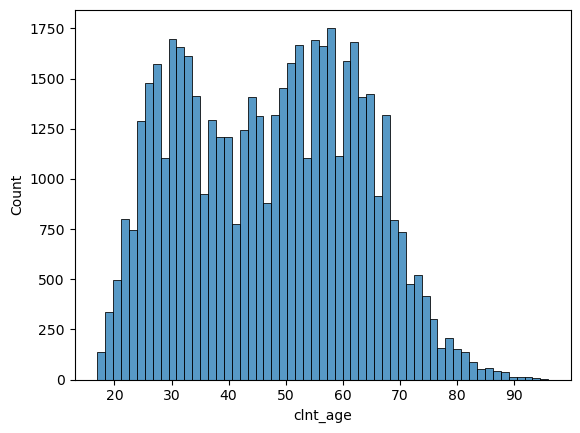

In [115]:
sns.histplot(df_clients["clnt_age"])

In [62]:
# Exploring gender distribution  

gender_distribution = pd.crosstab(index = df_clients["gendr"], columns = "Count")
gender_distribution

col_0,Count
gendr,
F,16259
M,16947
U,17280
X,2


In [ ]:
# Calculate the mean value of the selected variables based by gender 

df_by_gender = df_clients.groupby("gendr")[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "bal", "calls_6_mnth", "logons_6_mnth"]].mean()
df_by_gender 

,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,bal,calls_6_mnth,logons_6_mnth
gendr,,,,,,
F,14.771511,183.170367,50.423730,139076.096182,2.799250,5.850298
M,14.860211,184.120847,49.495810,212772.560084,3.427273,6.462914
U,6.680093,86.543113,42.267014,97311.649729,3.042361,6.072106
X,10.000000,124.500000,33.000000,28408.845000,3.500000,6.500000


In [118]:
# Any big differences between control vs test groups 

df_clients.groupby("Variation")[["clnt_tenure_yr", "clnt_tenure_mnth", "clnt_age", "bal", "calls_6_mnth", "logons_6_mnth"]].mean()


,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,bal,calls_6_mnth,logons_6_mnth
Variation,,,,,,
Control,12.087686,151.060186,47.498427,150147.326660,3.129213,6.166277
Test,11.982901,149.852899,47.163922,148962.605032,3.061941,6.101851


In [ ]:
# Explore client tenuer in years
df_clients["clnt_tenure_yr"].describe()

count    50488.000000
mean        12.031730
std          6.860282
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: clnt_tenure_yr, dtype: float64

In [103]:
# Top 10 customer tenuer (years) 

top_tenuer_years = pd.crosstab(index=df_clients["clnt_tenure_yr"], columns = "Count").sort_values(by= "Count", ascending=False).head(10)
top_tenuer_years

col_0,Count
clnt_tenure_yr,
6.0,5063
5.0,4950
7.0,3572
4.0,3381
15.0,3278
8.0,2920
14.0,2640
13.0,2586
12.0,2553


<Axes: xlabel='clnt_tenure_yr', ylabel='Count'>

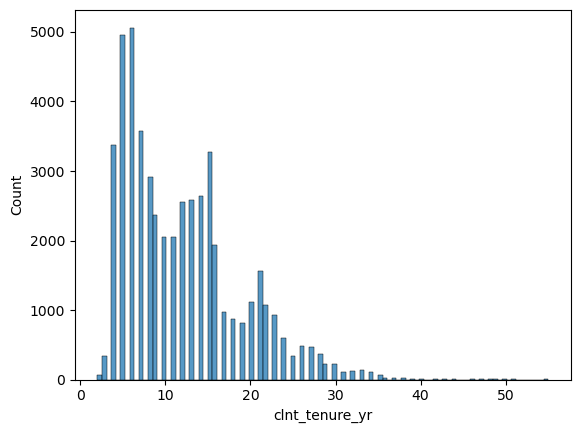

In [105]:
# Check distribution of tenuer(year)

sns.histplot(df_clients["clnt_tenure_yr"])

<Axes: xlabel='clnt_tenure_mnth', ylabel='Count'>

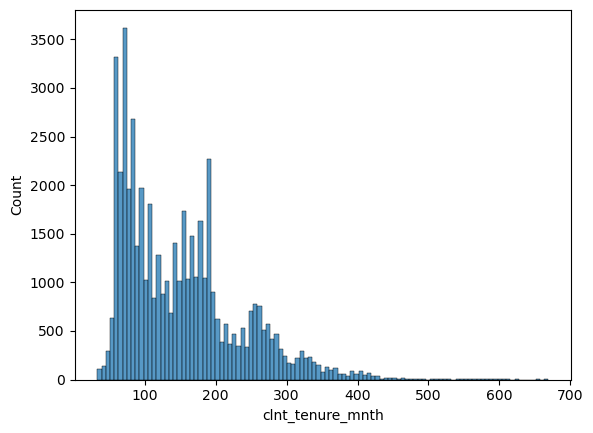

In [106]:
# Check distribution of tenuer(month)

sns.histplot(df_clients["clnt_tenure_mnth"])